# Preparing

## Importing Libraries

In [157]:
import pandas as pd
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import OLSInfluence
from ISLP import load_data
import numpy as np
import matplotlib.pyplot as plt


## Importing Dataframe

#### Page 130 - Exercise 10

In [158]:
df = load_data('Carseats')

print(df.dtypes, '\n')
print(f'Number of observations and features: {df.shape}')

Sales           float64
CompPrice         int64
Income            int64
Advertising       int64
Population        int64
Price             int64
ShelveLoc      category
Age               int64
Education         int64
Urban          category
US             category
dtype: object 

Number of observations and features: (400, 11)


## Dummying

Transforming the categorical variables into to dummies, removing the first observed value to avoid multicollinearity.

In [159]:
cols_categ = df.select_dtypes(include=['object', 'category']).columns.tolist()

df = pd.get_dummies(df, columns=cols_categ, drop_first=True, dtype=int)

df.head()

,Sales,CompPrice,Income,Advertising,Population,Price,Age,Education,ShelveLoc_Good,ShelveLoc_Medium,Urban_Yes,US_Yes
0,9.50,138,73,11,276,120,42,17,0,0,1,1
1,11.22,111,48,16,260,83,65,10,1,0,1,1
2,10.06,113,35,10,269,80,59,12,0,1,1,1
3,7.40,117,100,4,466,97,55,14,0,1,1,1
4,4.15,141,64,3,340,128,38,13,0,0,1,0


# Answers

### a) Fit a multiple regression model to predict Sales using Price, Urban and US.

In [160]:
df_feats = df[['Sales', 'Price', 'Urban_Yes', 'US_Yes']]

y = df['Sales']

X = df[['Price', 'Urban_Yes', 'US_Yes']]

X_const = sm.add_constant(X)

lin_reg_model = sm.OLS(y, X_const)

results = lin_reg_model.fit()

print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.239
Model:                            OLS   Adj. R-squared:                  0.234
Method:                 Least Squares   F-statistic:                     41.52
Date:                Sun, 21 Dec 2025   Prob (F-statistic):           2.39e-23
Time:                        00:53:40   Log-Likelihood:                -927.66
No. Observations:                 400   AIC:                             1863.
Df Residuals:                     396   BIC:                             1879.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         13.0435      0.651     20.036      0.0

### b) Provide an interpretation of each coefficient in the model. Be careful—some of the variables in the model are qualitative!

- General definition: the coeffiecient of a variable is the mean variation predicted for the dependent variable by a single unit (on numerical features, considering the other variables as constants), or the variation by the presence/absence of it (for categorical features represented converted as dummies - 0s and 1s).

- Interpretating each feature coefficient:
    - Price: as a numerical variable, the negative coefficient indicates that as higher the price is, smaller the sales will be, in the order of minus 0,0545 thousands;
    - Urban_Yes: as a dummy variable, it represents if the selling point is in a urban (1) or rural (0) location, meaning that if the selling point it's in a urban location, the sales are smaller, in the other of minus 0,219 thousands;
    - US_Yes: also a dummy variable, similarly to the previous feature, it represnts if the selling point is in the United States (1) or not (0), but in the opposite way it has a positive impact in the sales, in the order of 1,2006 thousands decrease.

### c) Write out the model in equation form, being careful to handle the qualitative variables properly.

```math
Sales = \beta_0 + \beta_1 \cdot Price + \beta_2 \cdot UrbanYes + \beta_3 \cdot USYes + \varepsilon

```math
\widehat{Sales}
=
\hat{\beta}_0
- 0.054 \cdot Price
+ \hat{\beta}_2 \cdot UrbanYes
+ 1.20 \cdot USYes

### d) For which of the predictors can you reject the null hypothesis H0 : βj = 0?

The relevance of an independent variable coefficient can be evaluated using the t-test, which assesses whether there is sufficient statistical evidence to reject the null hypothesis that the coefficient is equal to zero, at a given significance level.

It is important to note that failing to reject the null hypothesis does not necessarily imply that the variable has no effect on the target variable, but rather that there is insufficient evidence to confirm that it contributes to explain the target variable behavior.

Based on the t-test results and considering a significance level of 5%, we fail to reject the null hypothesis for the UrbanYes variable, since its p-value is 93.6%. This indicates that there is no statistical evidence of an association between Urban and Sales, and therefore this variable can be removed from the model.

Other commonly used significance levels include 1% and 10%, which however, the p-value for Urban_Yes is greater than all these thresholds, so the null hypothesis would not be rejected under any of them.

### e) On the basis of your response to the previous question, fit a smaller model that only uses the predictors for which there is evidence of association with the outcome.

In [161]:
df_feats_evidence = df[['Sales', 'Price', 'US_Yes']]

y = df['Sales']

X = df[['Price', 'US_Yes']]

X_const = sm.add_constant(X)

lin_reg_model = sm.OLS(y, X_const)

results = lin_reg_model.fit()

print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.239
Model:                            OLS   Adj. R-squared:                  0.235
Method:                 Least Squares   F-statistic:                     62.43
Date:                Sun, 21 Dec 2025   Prob (F-statistic):           2.66e-24
Time:                        00:53:40   Log-Likelihood:                -927.66
No. Observations:                 400   AIC:                             1861.
Df Residuals:                     397   BIC:                             1873.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         13.0308      0.631     20.652      0.0

### f) How well do the models in (a) and (e) fit the data?

Since the two linear regression models have a different number of features, and as the R-squared metric tends to inflate within the inclusion of new variables, it's advised the use of the Adjusted R-squared metric instead, that penalizes the variables not contributing to the target variable explanation.

In anyway, it can be verified that the removal of the 'Urban_Yes' variable due the lack of statistical evidence on explaining the Sales variable doesn't change the R-squared, what is expected since that is the reason why it has been removed. Similarly, the Adjusted R-squared slightly improves, which is also expected since all the features fitted in the model are relevant for the prediction and there's no longer penalty for the use of the irrelevant feature.

Additionally, it can also be verified that there was a increase on the F-statistic and its probability, which is also expected since this metric measures the statistical relevance of the model by its variables as a whole (not individually), which in essence confirms the evidence of at least one variable being statistically relevant to explain the Sales behavior explanation, not only its intercept.

### g) Using the model from (e), obtain 95 % confidence intervals for the coefficient(s).

The interval for Price [-0.065 to -0.044] is strictly negative, demonstrating a consistent inverse relationship where price hikes/drops inevitably lead to a reduction/increase in sales volume. Conversely, the US indicator variable shows a significant positive effect, with an interval of [0.692 to 1.708], which implies that US-based stores achieve higher sales outcomes compared to their non-US counterparts under identical conditions. The fact that zero falls outside both intervals allows us to reject the null hypothesis, which had already being confirmed in the item (d) by their correspondent p-values for the t-test.

### h) Is there evidence of outliers or high leverage observations in the model from (e)?

The Outliers (on linear regression models) and High Leverage observations are both related to distant values from their reference objects. 

The Outliers are calculated to evaluate big discrepancies on the model's residual values, which are the differences between the predicted and the observed values; the outliers calculation consist on converting the values as the number of standard deviations of the mean, making possible to identify these highly discrepant predictions - since they will be in a standardized scale, by setting a lower bound (1st Quartile - 1,5 x Inter Quartile Range) and an upper bound (3rd Quartile + 1,5 x Inter Quartile Range). The outliers don't follow the trend of the data, in this case, of the residual values.

Similarly, the High Leverage are extreme values of the features observations which drives them away from the mean of the other points, which is the linear regression trend line; this can be calculated by the hat-value metric, which consists on the definition of hat-matrix and checking its diagonal values exceeding a leverage threshold, defined by 2 x number of coefficients (including the intercept) / number of observations.

Isolatedly, these points are not synominous of influential behavior on the target variable prediction, but when occurring simultaneously they indicate the sensibility of the model, which can be calculated within the Cook's Distance metric, which measures the coefficients differences between the model with and without the influential points (both outliers and high leverage observation).

#### High Leverage Calculation

In [162]:
# influence diagnosis
influence = OLSInfluence(results)

# the high leverage values
leverage = influence.hat_matrix_diag

# defining the leverage threshold
p = results.df_model + 1    # coefficient numbers + the intercept
n = len(X_const)    # number of observations
leverage_threshold = 2 * p / n

# the high leverage values breaching the calculated threshold
high_leverage_threshold = X_const[leverage>leverage_threshold]

print(f'Number of High Leverage observations: {len(high_leverage_threshold)}')
print('\n', 'High Leverage observations')
high_leverage_threshold

Number of High Leverage observations: 20

 High Leverage observations


,const,Price,US_Yes
42,1.0,24,0
125,1.0,49,0
155,1.0,69,0
156,1.0,157,0
159,1.0,70,0
165,1.0,191,1
171,1.0,55,1
174,1.0,185,0
191,1.0,173,1
203,1.0,157,0


This result means that we have 20 high leverage points, that is, observations with the feature values dragging up or down the linear regression average line.

#### Residual Outliers Detection

In [163]:
# residual values standardized
studentized_residuals = influence.get_resid_studentized_external()

# outlier threshold definition, empyrically are 2 or 3
outlier_threshold = 3

# the observations where the residuals breach the limits
outlier_points = X_const[np.abs(studentized_residuals) > outlier_threshold] # residuals were absoluted to easy calculations

print(f'Number of Outliers Residuals: {len(outlier_points)}')
print('\n', 'Outliers Observations')
outlier_points

Number of Outliers Residuals: 0

 Outliers Observations


,const,Price,US_Yes


There are no outliers in the residuals, that is, all these values are following the data trend.

#### Cook's Distance Calculation

In [164]:
# cook's distance
cooks_distance = influence.cooks_distance[0] #the cook's distance it's a tuple of the influential points and their p-values

# setting cook's threshold
cooks_threshold = 4 / n

# defining influential points (both residuals outliers and high leverage observations)
influential_points = X_const[cooks_distance>cooks_threshold]

print(f'Number of Influential Points: {len(influential_points)}')
print('\n', 'Observations of Influential Points')
influential_points

Number of Influential Points: 19

 Observations of Influential Points


,const,Price,US_Yes
25,1.0,82,0
28,1.0,97,1
30,1.0,89,0
49,1.0,149,0
50,1.0,108,1
57,1.0,117,0
68,1.0,134,1
106,1.0,139,0
143,1.0,159,1
165,1.0,191,1


As state before, influential points are usually both outliers and high leverage observations, but even though the Cook's distance is returning 19 observations as such.

This not necessarily means that there are indeed influential points, cause this result is's a indication and the real impact of these supposedly observations should be compared by the comparison of the models with and without them, so there can be analyzed their real impact.

#### Plotting the Influence Chart

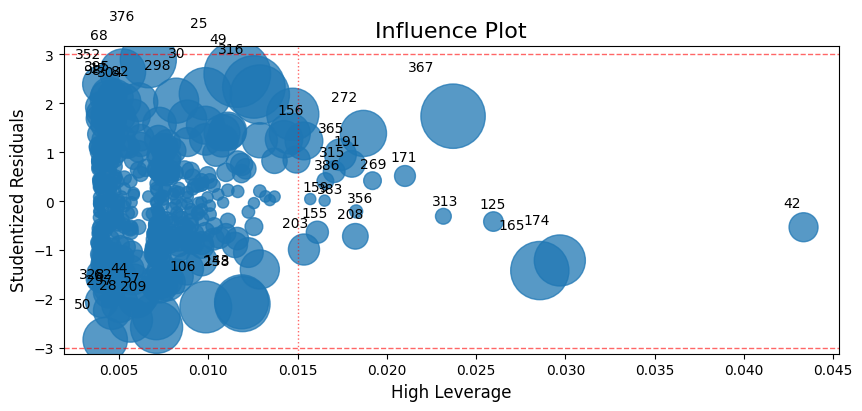

In [170]:
fig, ax = plt.subplots(figsize=(10, 4))
fig = sm.graphics.influence_plot(results, ax=ax, criterion="cooks", plot_alpha=0.75)

ax.set_title("Influence Plot", fontsize=16)
ax.set_ylabel("Studentized Residuals", fontsize=12)
ax.set_xlabel("High Leverage", fontsize=12)
for txt in ax.texts:
    txt.set_fontsize(10)

ax.axhline(outlier_threshold, linestyle="--", linewidth=1, alpha=0.6, color='red')
ax.axhline(-outlier_threshold, linestyle="--", linewidth=1, alpha=0.6, color='red')
ax.axvline(leverage_threshold, linestyle=":", linewidth=1, alpha=0.6, color='red')

plt.show()

The char above is a plot of the Studentized Residuals against the High Leverage observations, with their point size being displayed according to its calculated Cook's distance.

Regarding to the outliers, it can be visualized that there are no points threspassing it, even though it can be observed that as closer to the limits, the bigger the pointss circuferences are (i.e. the Cook's Distance), in the same, as much towards the right they are, the bigger they are (i.e. they have a higher leverage), with many points threpassing the vertical threshold.

Complementarly, even though there are not proper influential points by the criterion of observations been both outliers and high leverage points, it can be observed there are points very close to both outliers and high leverage thresholds, what explains that the isolated Cook's distance analysis points to the existence of influential points.

P.S.: the numbers displayed close to the points are the observations index.

#### Models with and without the Influential Points

As stated previously, the better way to verify the influential points real impact it's to compare the models with and without these points, which is presented below.

##### With Influential Points

In [166]:
lin_reg_model = sm.OLS(y, X_const)

results_inf = lin_reg_model.fit()

print(30*'-', 'WITH Influential Points', 30*'-', '\n')
print(results_inf.summary())

------------------------------ WITH Influential Points ------------------------------ 

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.239
Model:                            OLS   Adj. R-squared:                  0.235
Method:                 Least Squares   F-statistic:                     62.43
Date:                Sun, 21 Dec 2025   Prob (F-statistic):           2.66e-24
Time:                        00:53:40   Log-Likelihood:                -927.66
No. Observations:                 400   AIC:                             1861.
Df Residuals:                     397   BIC:                             1873.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------

##### Without Influential Points

In [167]:
# retrieving the influential observations indexes
influential_idx = np.where(cooks_distance > cooks_threshold)[0]

X_wo_inf = X_const.drop(index=influential_idx)
y_wo_inf = y.drop(index=influential_idx)

df_wo_inf = df_feats_evidence.drop(index=influential_idx) # drops from the df with the features with evidence

lin_reg_model_wo_inf = sm.OLS(y_wo_inf, X_wo_inf)

results_wo_inf = lin_reg_model_wo_inf.fit()

print(30*'-', 'WITHOUT Influential Points', 30*'-', '\n')
print(results_wo_inf.summary())

------------------------------ WITHOUT Influential Points ------------------------------ 

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.243
Model:                            OLS   Adj. R-squared:                  0.239
Method:                 Least Squares   F-statistic:                     60.75
Date:                Sun, 21 Dec 2025   Prob (F-statistic):           1.33e-23
Time:                        00:53:40   Log-Likelihood:                -843.09
No. Observations:                 381   AIC:                             1692.
Df Residuals:                     378   BIC:                             1704.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------

##### Plotting Partial Regressions

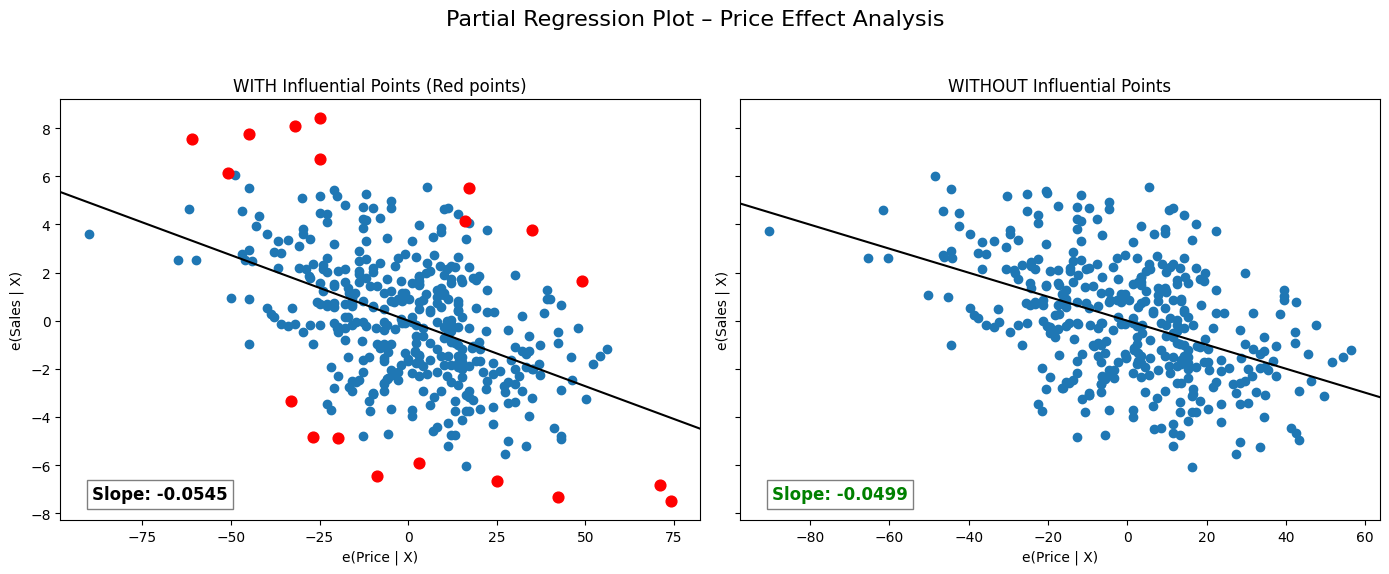

In [168]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

### model with influent points
sm.graphics.plot_partregress(
    'Sales', 'Price', ['US_Yes'],
    data=df_feats_evidence, obs_labels=False, ax=axes[0]
)

# setting the residual points locations
res_y = sm.OLS(df_feats_evidence['Sales'], sm.add_constant(df_feats_evidence['US_Yes'])).fit().resid
res_x = sm.OLS(df_feats_evidence['Price'], sm.add_constant(df_feats_evidence['US_Yes'])).fit().resid
axes[0].scatter(res_x.loc[influential_idx], res_y.loc[influential_idx], color='red', s=60, zorder=5, label='Influential')

# adding line slope
slope_1 = results.params['Price']
axes[0].text(0.05, 0.05, f'Slope: {slope_1:.4f}', transform=axes[0].transAxes, 
             fontsize=12, fontweight='bold', bbox=dict(facecolor='white', alpha=0.5))
axes[0].set_title("WITH Influential Points (Red points)")

### model without the influent points
sm.graphics.plot_partregress(
    'Sales', 'Price', ['US_Yes'],
    data=df_wo_inf, obs_labels=False, ax=axes[1]
)

# model without the influent points
slope_2 = results_wo_inf.params['Price']
axes[1].text(0.05, 0.05, f'Slope: {slope_2:.4f}', transform=axes[1].transAxes, 
             fontsize=12, fontweight='bold', bbox=dict(facecolor='white', alpha=0.5), color='green')
axes[1].set_title("WITHOUT Influential Points")

plt.suptitle("Partial Regression Plot – Price Effect Analysis", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

The chart above has the Linear Partial plot, which is the plot of the residual error of each predictor; on its Y-axis it has the impact of the US_Yes (in case there were other variables, they would also be included as well) over the Sales, and on the X-axis the Price over the Sales.

It's shown in red the influential points flagged and how they clearly are floating apart of the regression mean line, but not very agressively, since the majority of them are still close to other regular points, which make sense since there are not outliers detected.

Visually on the second plot, without the influential points, it can be observed that there seem's to have a better adjusment of the points to the linear regression line, and more objectively can be stated that there's indeed a change on the model, since the slope value changes (from -0,0545 to -0,0499).

### Conclusion

* There's no evidence of outliers but there are high leverage observations, and that even though there are influential observations stated by the Cook's distance metric;
* The result of this analysis shows a slight increase of the Adjust R-squared (from 0,235 to 0,239), but not enough to affirm that the model is highly sensiblen to the suposedly influential points;
* It can also be verified by the features impact on the Sales remaining statistically relevant, since the p-values of the t-test remain below the 95% level of confidence, similarly also the confidence intervals which still not cross the zero value;
* Additionally, there was a small reduction on the confidence interval amplitude, but as expected by analyzing the Adjusted R-squared, it may not generate real significant impact;
* Therefore, it can be concluded that even though the model has influential points by the Cook's distance, they are not impacting the model in a relevant way;
* This similar conclusion can be reached by using the partial regression plot above, where there is a change on the line slope, which means that the line was readjusted but not in a significant value.